In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import pyarrow
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Data

In [2]:
features_df = pd.read_parquet(r"..\data\features\features.parquet", engine="pyarrow")

# Data preprocessing

In [3]:
# Mobile mean with a window of one hour
hours = 1
# Apply filters to the time series of the features
features_df = features_df[(features_df['energy']>=0)&(features_df['kurtosis']<2500)&(features_df['frequency_index']>=-3)&(features_df['entropy']>=0)&(features_df['entropy']<15000)]
# Calculate moving average for all features
features_df['energy_mobile_mean'] = np.log10(features_df['energy'].rolling(window=11*hours, center=False).mean())
features_df['kurtosis_mobile_mean'] = np.log10(features_df['kurtosis'].rolling(window=11*hours, center=False).mean())
features_df['frequency_index_mobile_mean'] = features_df['frequency_index'].rolling(window=11*hours, center=False).mean()
features_df['entropy_mobile_mean'] = features_df['entropy'].rolling(window=11*hours, center=False).mean()
features_df['energy'] = np.log10(features_df['energy'])
features_df['kurtosis'] = np.log10(features_df['kurtosis'])

## Training set

In [4]:
features_df_1_month = features_df[features_df['timestamp']<"2022-02-01"]

In [16]:
features_df_1_month.tail(10)

,timestamp,energy,kurtosis,frecuency_index,entropy,frequency_index,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean
8887,2022-01-31 23:10:00,8.458819,0.934692,None,2066.250901,0.428718,8.416345,1.269300,0.263293,2190.311041
8888,2022-01-31 23:15:00,8.512041,0.784324,None,1906.936757,0.453839,8.429139,1.270355,0.295809,2169.113673
8889,2022-01-31 23:20:00,8.184431,0.775495,None,2594.243250,0.309602,8.426481,1.272117,0.305697,2183.353417
8890,2022-01-31 23:25:00,7.983301,0.689003,None,3074.642716,0.234061,8.422826,1.273646,0.301972,2212.113807
8891,2022-01-31 23:30:00,8.146123,0.631790,None,2614.453517,0.261338,8.419812,1.271173,0.297344,2221.718683
8892,2022-01-31 23:35:00,8.830721,2.334161,None,1668.982751,0.629002,8.471704,1.573340,0.347591,2194.681709
8893,2022-01-31 23:40:00,8.817154,2.361190,None,1705.372009,0.451853,8.512201,1.760099,0.385613,2178.716875
8894,2022-01-31 23:45:00,8.051987,0.780485,None,2927.230991,0.083474,8.474237,1.714692,0.360933,2273.282381
8895,2022-01-31 23:50:00,7.990021,0.815191,None,3100.668472,0.158434,8.432990,1.659252,0.330689,2379.334500
8896,2022-01-31 23:55:00,7.809566,0.646664,None,3571.532223,0.084493,8.408701,1.658216,0.311298,2504.655076


In [18]:
# Take descriptive variables
variables = ["energy_mobile_mean",	"kurtosis_mobile_mean", "frequency_index_mobile_mean", "entropy_mobile_mean"]
X = features_df_1_month[["energy_mobile_mean",	"kurtosis_mobile_mean",	
                         "frequency_index_mobile_mean", "entropy_mobile_mean"]].dropna().to_numpy()

print(X.shape)
print(X[0:4,])

(8883, 4)
[[7.18982353e+00 1.01675610e+00 2.80678919e-03 6.56696312e+03]
 [7.20203479e+00 1.13528158e+00 4.02816503e-02 6.54176382e+03]
 [7.21758234e+00 1.22597677e+00 8.77315784e-02 6.48441711e+03]
 [7.21492101e+00 1.22188196e+00 9.13598157e-02 6.50112491e+03]]


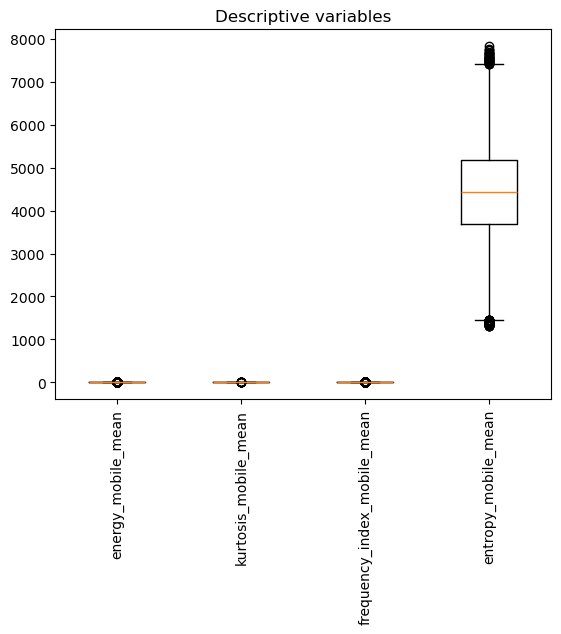

In [19]:
# See distribution of variables
plt.title('Descriptive variables')
plt.boxplot(X)
plt.xticks(ticks=range(1, 5), labels=variables, rotation=90)
plt.show()

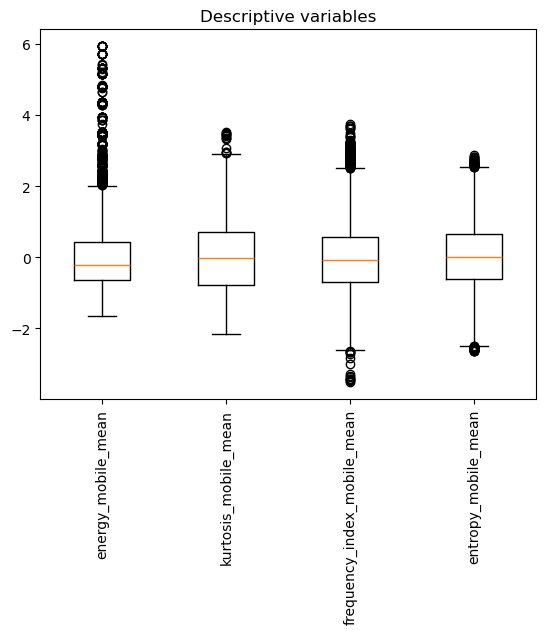

In [21]:
# Scale and plot again
scaler = StandardScaler().fit(X)
X = scaler.transform(X)
plt.title('Descriptive variables')
plt.boxplot(X)
plt.xticks(ticks=range(1, 5), labels=variables, rotation=90)
plt.show()

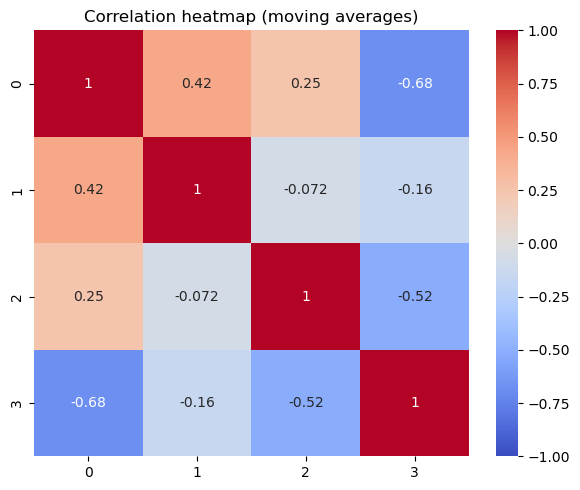

In [22]:
import seaborn as sns
# Compute correlation matrix
corr = pd.DataFrame(data=X).corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation heatmap (moving averages)')
plt.tight_layout()
plt.show()

## Dimensionality reduction

### PCA

In [23]:
# Train a PCA model
pcs = PCA(n_components=4).fit(X)
pcs

PCA(n_components=4)

In [24]:
# Report PCA summary
pcsSummary = pd.DataFrame({'Standard deviation': np.sqrt(pcs.explained_variance_),
                           'Proportion of variance': pcs.explained_variance_ratio_,
                           'Cumulative variance': np.cumsum(pcs.explained_variance_ratio_)})

pcsSummary = pcsSummary.transpose()
pcsSummary.columns = ['PC'+str(ind) for ind in range(1, 5)]
pcsSummary.round(3)

,PC1,PC2,PC3,PC4
Standard deviation,1.443,1.074,0.728,0.484
Proportion of variance,0.520,0.288,0.133,0.059
Cumulative variance,0.520,0.809,0.941,1.000


In [25]:
# See the weights for each PC
pcsComponents = pd.DataFrame(pcs.components_.transpose(),
                             columns=['PC'+str(ind) for ind in range(1, 5)],
                             index= variables)

pcsComponents

,PC1,PC2,PC3,PC4
energy_mobile_mean,-0.599894,0.238637,-0.404539,0.647710
kurtosis_mobile_mean,-0.295610,0.744349,0.566410,-0.194268
frequency_index_mobile_mean,-0.414479,-0.594248,0.646543,0.238869
entropy_mobile_mean,0.617211,0.189385,0.312267,0.696903


In [26]:
# Apply PCA transformation to original data
Z = pd.DataFrame(pcs.transform(X), columns=['PC'+str(ind) for ind in range(1, 5)])
Z

,PC1,PC2,PC3,PC4
0,2.093583,-0.309114,0.587753,0.571268
1,1.867200,-0.188118,0.922386,0.558369
2,1.618884,-0.169109,1.240274,0.561112
3,1.624468,-0.190031,1.254425,0.575781
4,1.677512,-0.163761,1.226588,0.584458
...,...,...,...,...
8878,-2.889028,-0.550255,0.871009,-0.381807
8879,-3.200530,-0.268676,1.304477,-0.396042
8880,-3.008374,-0.276563,1.179913,-0.393539
8881,-2.783635,-0.285189,1.021345,-0.390519


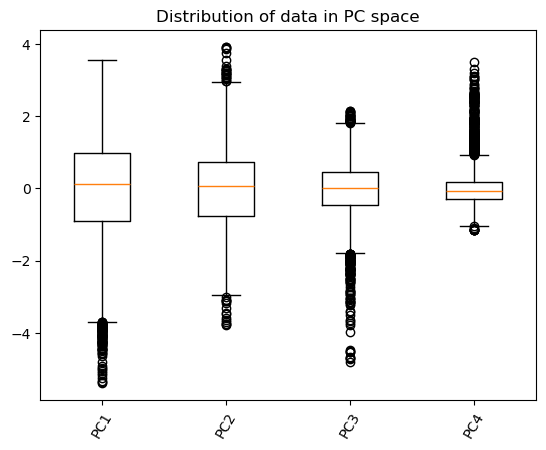

In [27]:
# Plot distribution of data
plt.title('Distribution of data in PC space')
plt.boxplot(pcs.transform(X))
plt.xticks(ticks=range(1, 5), labels=['PC'+str(ind) for ind in range(1, 5)], rotation=60)
plt.show()

### Model

In [28]:
# Create a PCA object and train it
pca = PCA(n_components=2).fit(X)
# Transform the data to the new reducted space
Z = pca.transform(X)
print(Z.shape)

(8883, 2)


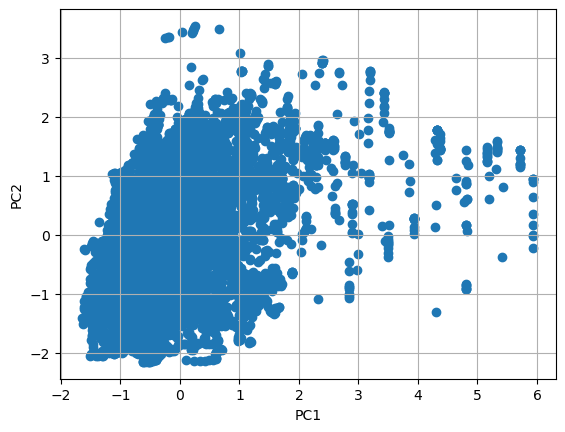

In [29]:
# Plot in the new space
plt.scatter(X[:, 0], X[:, 1])
plt.grid()
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

#### Clustering

In [31]:
# Try with different number of groups
inertia = []
silh = []
k_s = np.arange(2, 16)
for k in k_s:
  km_model = KMeans(n_clusters=k).fit(Z)
  inertia.append(km_model.inertia_)
  silh.append(silhouette_score(Z, km_model.labels_))

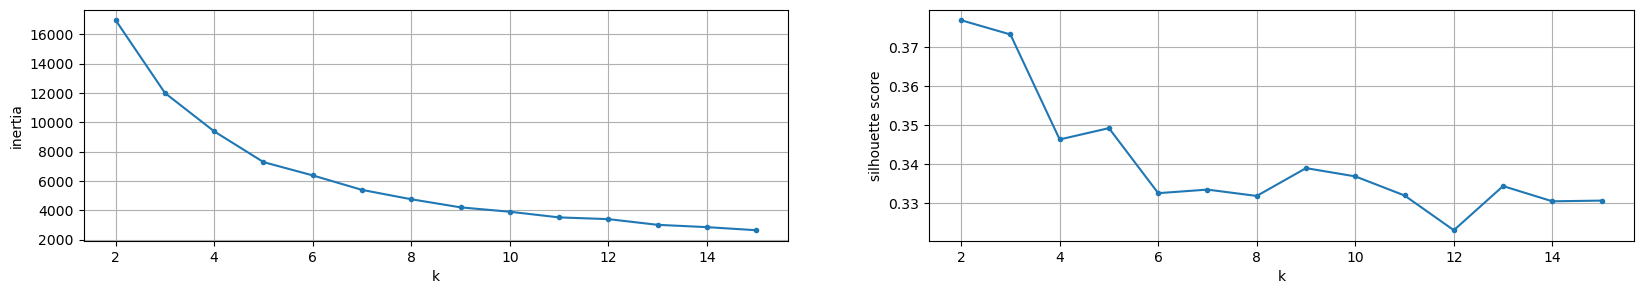

In [32]:
# Plot results
plt.figure(figsize=(20, 3))
plt.subplot(1, 2, 1)
plt.plot(k_s, inertia, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('inertia')
plt.subplot(1, 2, 2)
plt.plot(k_s, silh, '.-')
plt.grid()
plt.xlabel('k')
plt.ylabel('silhouette score')
plt.show()

In [33]:
# Select a number of four groups
km_model = KMeans(n_clusters=4).fit(Z)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


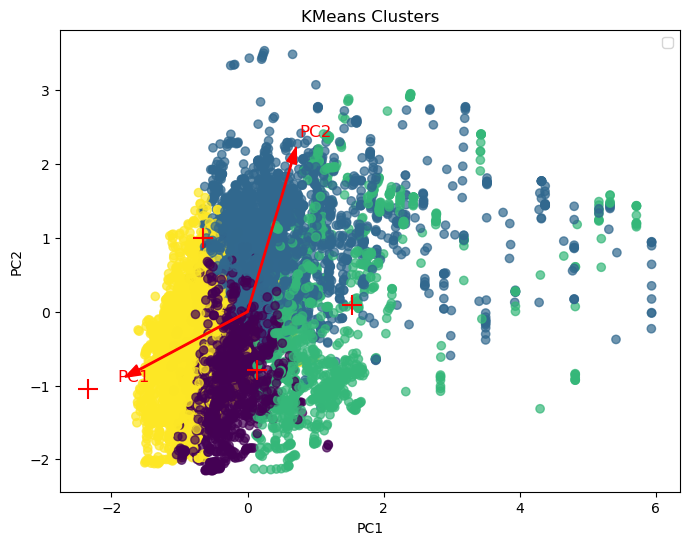

In [55]:
labels = km_model.labels_
centroids = km_model.cluster_centers_
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='+')
# Plot principal component axes
origin = np.mean(X[:, :2], axis=0)
for i, (vec, var) in enumerate(zip(pca.components_[:2], pca.explained_variance_ratio_[:2])):
    plt.arrow(origin[0], origin[1], vec[0]*3, vec[1]*3, color='red', width=0.02, head_width=0.15, length_includes_head=True)
    plt.text(origin[0] + vec[0]*3.2, origin[1] + vec[1]*3.2, f'PC{i+1}', color='red', fontsize=12)
plt.title('KMeans Clusters')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

In [48]:
clustering_data = pd.DataFrame(X, columns= variables)
clustering_data['timestamp'] = features_df_1_month['timestamp']
clustering_data['labels'] = km_model.labels_

In [49]:
clustering_data.head()

,energy_mobile_mean,kurtosis_mobile_mean,frequency_index_mobile_mean,entropy_mobile_mean,timestamp,labels
0,-1.197447,-0.627043,-0.167590,1.815295,2022-01-01 00:05:00,3
1,-1.176493,-0.278013,0.067613,1.793989,2022-01-01 00:10:00,3
2,-1.149815,-0.010937,0.365423,1.745503,2022-01-01 00:15:00,3
3,-1.154382,-0.022996,0.388194,1.759629,2022-01-01 00:20:00,3
4,-1.163051,-0.036575,0.334672,1.794698,2022-01-01 00:25:00,3


In [51]:
clustering_data = clustering_data.dropna()

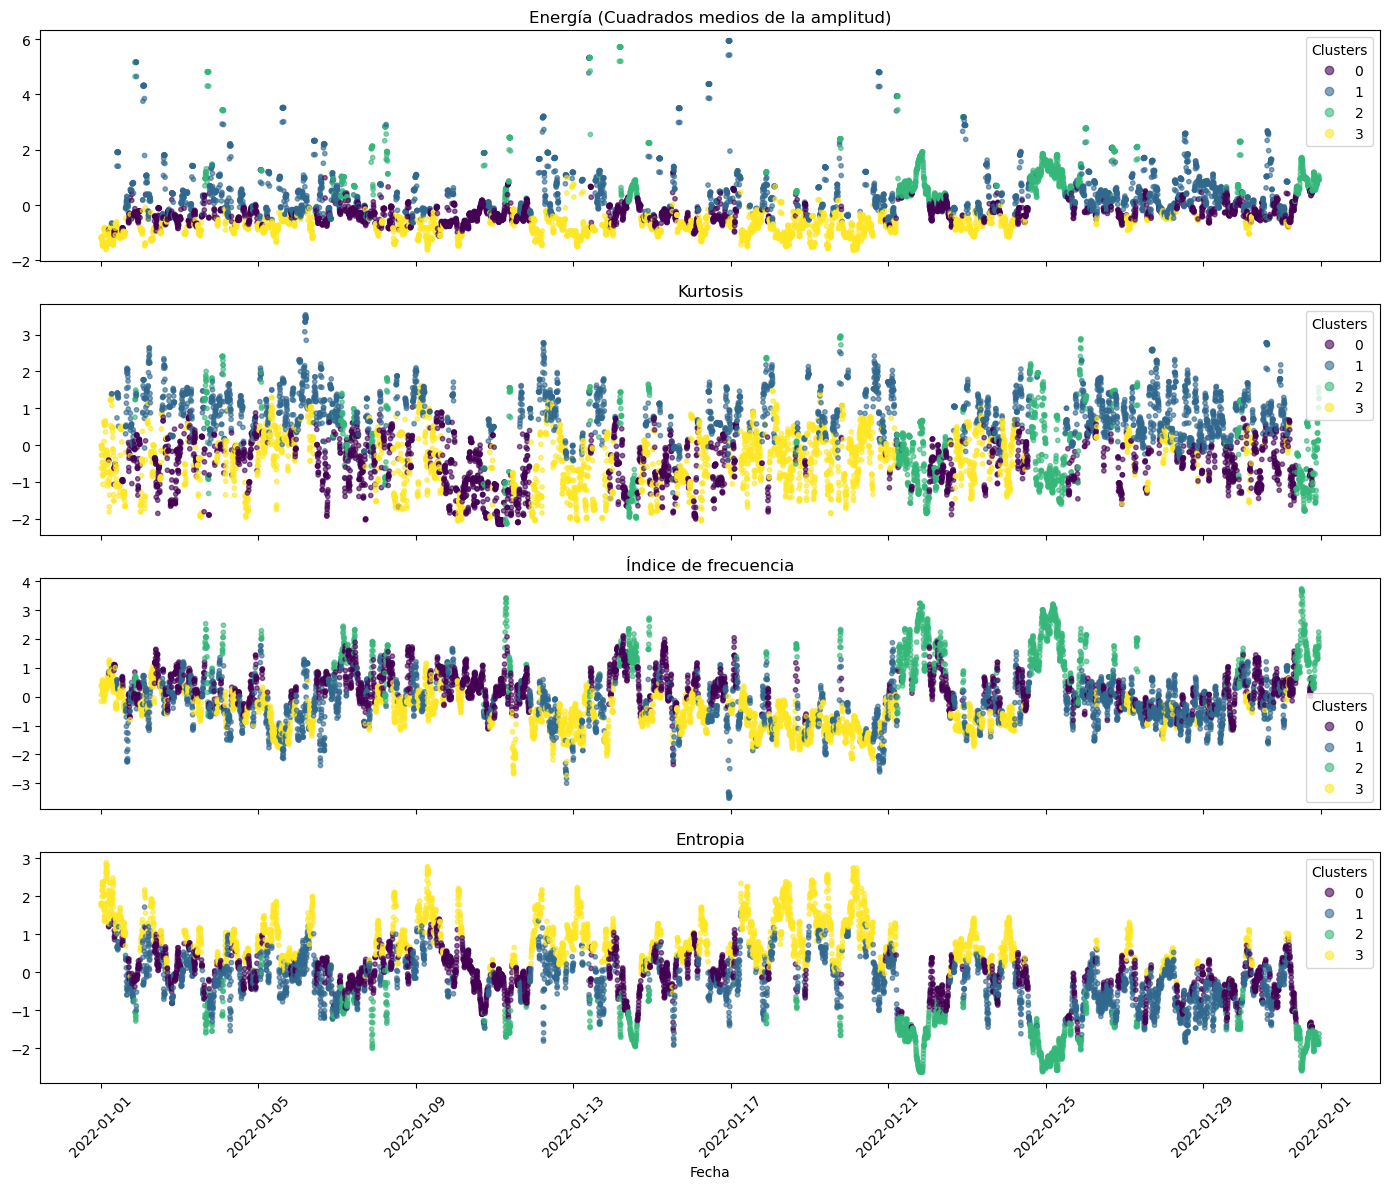

In [52]:
# Generate the plot
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(14, 12), sharex=True)
scatter = axes[0].scatter(clustering_data['timestamp'], clustering_data['energy_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[0].set_title('Energía (Cuadrados medios de la amplitud)')
axes[0].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[1].scatter(clustering_data['timestamp'], clustering_data['kurtosis_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[1].set_title('Kurtosis')
axes[1].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[2].scatter(clustering_data['timestamp'], clustering_data['frequency_index_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[2].set_title('Índice de frecuencia')
axes[2].legend(*scatter.legend_elements(), title="Clusters")

scatter = axes[3].scatter(clustering_data['timestamp'], clustering_data['entropy_mobile_mean'], c=clustering_data['labels'], cmap='viridis', s=10, alpha=0.6)
axes[3].set_title('Entropia')
axes[3].set_xlabel('Fecha')
axes[3].legend(*scatter.legend_elements(), title="Clusters")

plt.xticks(rotation=45)
plt.tight_layout()